# Análisis predictivo de deserción estudiantil

El CSV original del panel tiene 20 filas agregadas por año y semestre, 10 perfiles anuales repetidos entre Spring y Fall, y ninguna etiqueta individual de deserción. Por ello, el modelo usa el conjunto [UCI 697](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success), con licencia CC BY 4.0. Los datos proceden de una institución portuguesa y no representan a la Universidad de la Costa.

La tarea es clasificar `Dropout`, `Enrolled` y `Graduate` con variables conocidas hasta el final del primer semestre. Las variables del segundo semestre y las macroeconómicas se excluyen.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from analysis.train_model import DATA_PATH, CLASSES, prepare_data, run_training

sns.set_theme(style='whitegrid')
original = pd.read_csv('university_student_data.csv')
print('CSV original:', original.shape, '| filas anuales únicas:', original.drop(columns='Term').drop_duplicates().shape[0])
print('Columnas originales:', original.columns.tolist())
features, target, audit = prepare_data(DATA_PATH)
print('Auditoría UCI:', audit)
display(features.head())


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\EDMR\\AppData\\Local\\matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


CSV original: (20, 11) | filas anuales únicas: 10
Columnas originales: ['Year', 'Term', 'Applications', 'Admitted', 'Enrolled', 'Retention Rate (%)', 'Student Satisfaction (%)', 'Engineering Enrolled', 'Business Enrolled', 'Arts Enrolled', 'Science Enrolled']
Auditoría UCI: {'rows': 4424, 'columns': 37, 'missing_cells': 0, 'exact_duplicate_rows': 0, 'class_counts': {'Dropout': 1421, 'Enrolled': 794, 'Graduate': 2209}, 'excluded_features': ['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP'], 'features_used': ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations)
0,1,17,5,171,1,1,122.0,1,19,12,...,1,0,20,0,0,0,0,0,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,1,0,19,0,0,6,6,6,14.000000,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,1,0,19,0,0,6,0,0,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,20,0,0,6,8,6,13.428571,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,45,0,0,6,9,5,12.333333,0


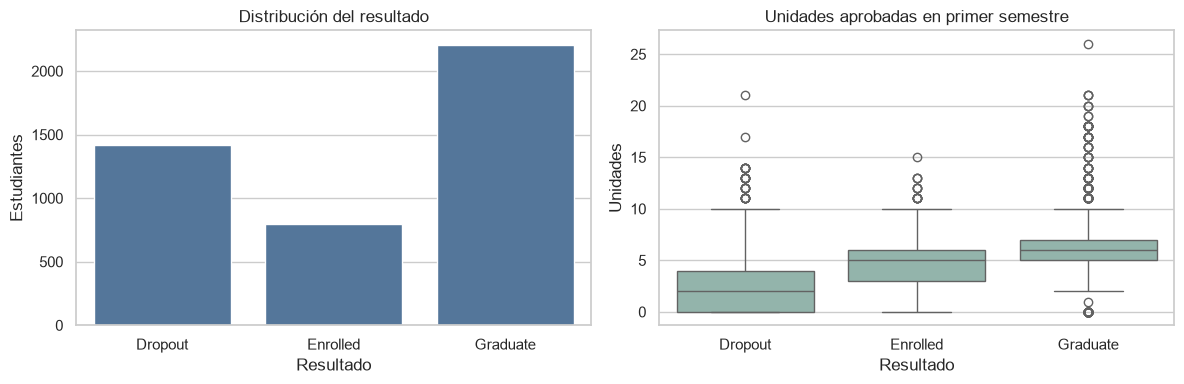

Nulos por variable: {}


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=target, order=CLASSES, ax=axes[0], color='#4976a5')
axes[0].set(title='Distribución del resultado', xlabel='Resultado', ylabel='Estudiantes')
sns.boxplot(data=features.assign(Target=target), x='Target', y='Curricular units 1st sem (approved)', order=CLASSES, ax=axes[1], color='#8eb9ad')
axes[1].set(title='Unidades aprobadas en primer semestre', xlabel='Resultado', ylabel='Unidades')
plt.tight_layout()
plt.show()
print('Nulos por variable:', features.isna().sum()[lambda x: x > 0].to_dict())


## Entrenamiento y evaluación

`analysis.train_model` contiene el flujo reproducible: separación estratificada 80/20, imputación y codificación ajustadas solo sobre entrenamiento, bosque aleatorio, validación cruzada de cinco pliegues en entrenamiento y evaluación final en prueba. La referencia siempre predice la clase más frecuente. La importancia por permutación mide pérdida de F1 macro; no demuestra causalidad.

Validación cruzada: {'test_f1_macro': {'mean': 0.6786580060277443, 'std': 0.026963319552154377}, 'test_recall_macro': {'mean': 0.674920585460762, 'std': 0.0259180751704604}}
Referencia: {'f1_macro': 0.22205476011052497, 'dropout_recall': 0.0}
Prueba: F1 macro = 0.663 | recall Dropout = 0.701


,precision,recall,f1-score,support
Dropout,0.756654,0.700704,0.727605,284.0
Enrolled,0.426136,0.471698,0.447761,159.0
Graduate,0.809417,0.816742,0.813063,442.0


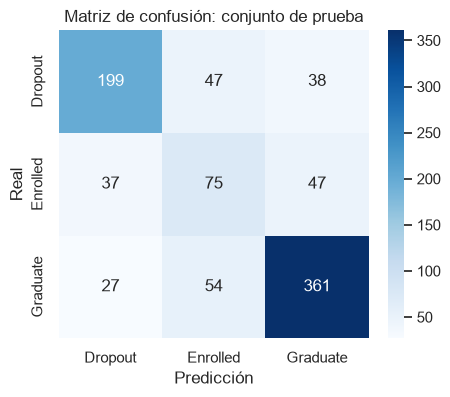

In [3]:
results = run_training()
print('Validación cruzada:', results['cross_validation_train'])
print('Referencia:', results['baseline_test'])
print('Prueba: F1 macro =', round(results['test']['f1_macro'], 3), '| recall Dropout =', round(results['test']['dropout_recall'], 3))
report = results['test']['classification_report']
display(pd.DataFrame(report).T.loc[CLASSES, ['precision', 'recall', 'f1-score', 'support']])
matrix = pd.DataFrame(results['test']['confusion_matrix'], index=CLASSES, columns=CLASSES)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set(xlabel='Predicción', ylabel='Real', title='Matriz de confusión: conjunto de prueba')
plt.show()


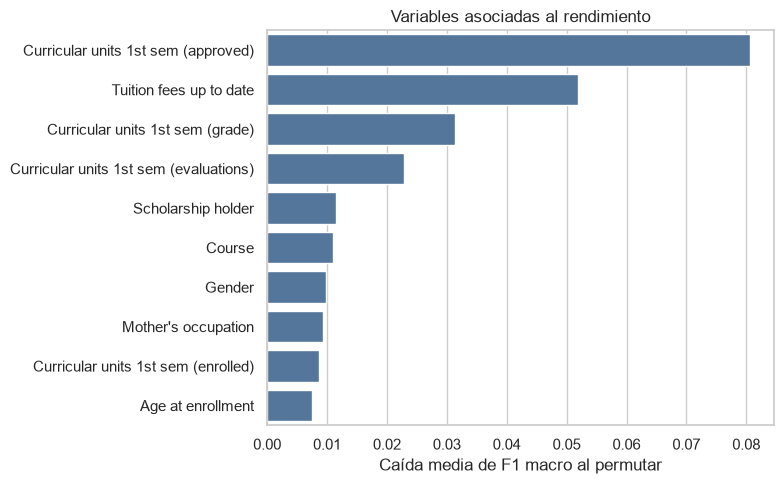

In [4]:
importance = pd.read_csv('results/permutation_importance.csv').head(10)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance, y='feature', x='importance_mean', color='#4976a5', ax=ax)
ax.set(xlabel='Caída media de F1 macro al permutar', ylabel='', title='Variables asociadas al rendimiento')
plt.tight_layout()
plt.show()


## Límites

`Enrolled` representa un estado aún no resuelto. No hay identificadores de cohorte ni año por estudiante para validar en el tiempo. El conjunto procede de una sola institución extranjera; las métricas no garantizan rendimiento local. Las asociaciones del modelo no implican causas ni justifican decisiones individuales automáticas.